# Exercise 3: Time series with ARIMA

## Do not start the exercise until you fully understand the submission guidelines.

- The homework assignments are executed automatically.
- Failure to comply with the following instructions will result in a significant penalty.
- Appeals regarding your failure to read these instructions will be denied.
- Kind reminder: the homework assignments contribute 60% of the final grade.

## Read the following instructions carefully:

1. This Jupyter notebook contains all the step-by-step instructions needed for this exercise.
1. Write **efficient**, **vectorized** code whenever possible. Some calculations in this exercise may take several minutes when implemented efficiently, and might take much longer otherwise. Unnecessary loops will result in point deductions.
1. You are responsible for the correctness of your code and should add as many tests as you see fit to this jupyter notebook. Tests will not be graded nor checked.
1. You are allowed to use functions and methods from the [Python Standard Library](https://docs.python.org/3/library/).
1. Your code must run without errors. Use at least `numpy` 1.15.4. Any code that cannot run will not be graded.
1. Write your own code. Cheating will not be tolerated.
1. Submission includes a zip file that contains this notebook, with your ID as the file name. For example, `hw1_123456789_987654321.zip` if you submitted in pairs and `hw1_123456789.zip` if you submitted the exercise alone. The name of the notebook should follow the same structure.

Please use only a **zip** file in your submission.

---

---

## Please sign that you have read and understood the instructions:

316492776
318900016

---

---


In [1]:
!pip3 install -q statsmodels seaborn numpy pandas scikit-learn yfinance

In [2]:
# Import necessary libraries
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yfinance as yf
from sklearn.linear_model import LinearRegression
from statsmodels.graphics import tsaplots
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import acf, adfuller, pacf

sns.set_theme()
np.random.seed(42)

# Algorithm overview

Make sure to describe the algorithm, its limitations, and describe use-cases.


ARIMA - AutoRegressive Integrated Moving Average is a statistical algorithm for time series forecasting.

It consists of 3 parts:

1. Auto Regression (AR) - Use past observations in order to predict next values
2. Integration (I) - Differentiate data in units in order to work with stationarity data
3. Moving Average (MA) - Estimate errors in order to tune future predictions

Its main focus is forecasting future values based on past values in time series with stationary data (or an integration of stationary data) and its best for use cases which the data has a strong correlation. Examples of such cases are stock price prediction, sales and inventory levels prediction.

However, when the data doesn't have a stationarity and constant trend patterns, ARIMA may fail to make a useful forecasting.
In this project we're going to use a real dataset which is a typical one for ARIMA algorithm - the daily stock price of Amazon inc. since it has been started trading untill lately.


# Your implementations

You may add new cells, write helper functions or test code as you see fit.
Please use the cell below and include a description of your implementation.
Explain code design consideration, algorithmic choices and any other details you think is relevant to understanding your implementation.
Failing to explain your code will lead to point deductions.


Our implementation consists on ARMA base class with a "layer" of differentiation upon it which makes it ARIMA. We implemented this using inheritance,
which makes the code short, readable and easy to extend. We made sure that everything is vectorized and avoided loops as much as we could.
In terms of extra features we added:

- an option to manually pass the order of the ARIMA (p,d,q). By default these parameters are automatically deduced from the given data using ACF and PACF values as seen in the lecture.
- verbosity option for easy debugging
- the ability to calibrate the also the autocorrelation significance threshold. A large thrshold means less parameters hence a simpler model, at the risk of underfitting. Smaller threshold will cause more parameters and risk overfitting.

The implementation works as follows:

1. [ARIMA only, if d is not set] Differentiation is calculated - the decision whether to differentiate is taken based on the stationarity of the data, which we calculate using Augmented Dickey–Fuller test. We allow d to be only 0,1 or 2, since higher orders are very unlikely to occur naturally.
2. [if p,q are not set] We calculate p,q - as seen in class, we calculate ACF and PACF values, setting p,d according to where the correlation stops being significant.
3. We fit the AR model - using the last p observations to predict the next one, we fit a linear regressor to find the best $\phi_i$ for the given data.
4. We fit the MA model - using the last q _errors_ (which are calculated by the difference between the actual value and the AR estimation) to predict the next error we decide what should be the correction to tweak the AR. We again use a (different) linear regressor to find the best $\theta_j$.
5. Now that the model is calibrated, we can predict the next values using $x_t=\sum_{i=1}^{p}{\phi_i x_{t-i}}+\sum_{j=1}^{q}{\theta_j w_{t-j}}$ with the parameters computed before and noise estimation in each prediction step.
6. [ARIMA only, if d > 0] Since we run on differentiated values we need to integrate back to the get the data and not its derivatives.


In [3]:
class ARMACustom:
    def __init__(
        self,
        X: np.ndarray,
        order: tuple = (None, None),
        verbose: bool = False,
        ac_thresh: float = 0.1,
    ):
        self.verbose = verbose
        self.ac_thresh = ac_thresh
        self.X = X
        self.order = order
        self.set_params()

    def set_params(self):
        self.p, self.q = self.order

    def fit(self) -> None:
        self.find_p()
        self.find_q()
        self.fit_AR()
        self.fit_MA()

    def find_p(self) -> None:
        if self.p is not None:
            return None
        X_pacf = pacf(self.X)
        p = np.argmax(np.abs(X_pacf) < self.ac_thresh)
        if self.verbose:
            print(f"{p=}")
            print(f"pacf={X_pacf}")
        assert 0 < p < len(self.X), "Cannot fit AR model to the given data"
        self.p = p

    def find_q(self) -> None:
        if self.q is not None:
            return None
        X_acf = acf(self.X)
        q = np.argmax(np.abs(X_acf) < self.ac_thresh)
        if self.verbose:
            print(f"{q=}")
            print(f"acf={X_acf}")
        assert 0 < q < len(self.X), "Cannot fit MA model to the given data"
        self.q = q

    def fit_AR(self) -> None:
        if self.p == 0:
            self.phi_ = np.array([])
            return None
        data = np.vstack([self.X[i - self.p : i] for i in range(self.p, len(self.X))])
        labels = self.X[self.p : len(self.X)]
        reg = LinearRegression(fit_intercept=False).fit(data, labels)
        self.phi_ = reg.coef_
        if self.verbose:
            print(f"{self.phi_=}")
            print(f"AR R2={reg.score(data, labels):.3f}")

    def fit_MA(self) -> None:
        if self.q == 0:
            self.theta_ = np.array([])
            return None
        w = np.zeros(len(self.X))
        for i in range(self.p, len(self.X)):
            ar = np.dot(self.phi_, self.X[i - self.p : i])
            w[i] = self.X[i] - ar
        # we start from p+q since it is the first index that allows full derivation of errors looking back in time
        labels = w[self.q + self.p : len(self.X)]
        data = np.vstack(
            [w[i - self.q : i] for i in range(self.q + self.p, len(self.X))]
        )
        reg = LinearRegression(fit_intercept=False).fit(data, labels)
        self.theta_ = reg.coef_
        if self.verbose:
            print(f"{self.theta_=}")
            print(f"MA R2={reg.score(data, labels):.3f}")

    def forecast(self, steps: int) -> np.ndarray:
        n = len(self.X)
        preds = np.concatenate([self.X, np.zeros(steps)])
        noise_preds = np.zeros_like(preds)  # same size for vectorization
        for i in range(
            n - self.p, n + steps
        ):  # we go back p steps to estimate the noise
            ar = np.dot(self.phi_, preds[i - self.p : i])
            ma = np.dot(self.theta_, noise_preds[i - self.q : i])
            if i >= n:
                preds[i] = ar + ma  # we change only future indexes
            else:
                noise_preds[i] = preds[i] - ar - ma
                # will be 0 for new indexes, since we don't know X[i] for i >= n
        return preds[n:]
    
    def __str__(self):
        string = f"x_n = "
        for i, phi in enumerate(self.phi_[::-1]):
            string += f"{phi:+.3f}x_{{n-{i+1}}}"
        for j, theta in enumerate(self.theta_[::-1]):
            string += f"{theta:+.3f}w_{{n-{j+1}}}"
        return f"${string}$"


class ARIMACustom(ARMACustom):
    def __init__(
        self,
        X: np.ndarray,
        order: tuple = (None, None, None),
        verbose=False,
        ac_thresh: float = 0.1,
        stationarity_conf: float = 0.05,
    ):
        super().__init__(X, order, verbose, ac_thresh)
        self.stationarity_conf = stationarity_conf

    def set_params(self):
        self.p, self.d, self.q = self.order

    def find_d(self) -> None:
        if self.d is not None:
            return None
        for d in [0, 1, 2]:  # no more than a second derivative
            p_val = adfuller(np.diff(self.X, d))[1]  # p-value
            if p_val < self.stationarity_conf:
                if self.verbose:
                    print(f"{p_val=}")
                    print(f"{d=}")
                self.d = d
                return None
        raise Exception("Data is not stationary, even after differentiating twice")

    def fit_I(self) -> None:
        self.Z = np.copy(self.X)  # to maintain inheritance
        self.X = np.diff(self.X, self.d)

    def fit(self) -> None:
        self.find_d()
        self.fit_I()
        super().fit()

    def forecast(self, steps: int) -> np.ndarray:
        match self.d:
            case 0:
                return super().forecast(steps)
            case 1:
                # TODO: fix because Z[-1] is repeated twice (maybe just remove it)
                dx = np.insert(super().forecast(steps).cumsum(), 0, 0) + self.Z[-1]
                dx = super().forecast(steps).cumsum() + self.Z[-1]
                return super().forecast(steps).cumsum() + self.Z[-1]
            case 2:
                # insert 0 at the beggining to maintain size
                dx = (
                    np.insert(super().forecast(steps - 1).cumsum(), 0, 0)
                    + self.Z[-1]
                    - self.Z[-2]
                )
                return dx.cumsum() + self.Z[-1]
            case _:
                raise Exception(f"{self.d=} which is invalid")
            
    def __str__(self):
        return f"[{self.d} derivative] {super().__str__()}"

We also implemented two important visualization functions that will help us through the whole notebook

In [4]:
def plot_correlation_graphs(values):
    plt.rcParams.update({"figure.figsize": (20, 5), "figure.dpi": 120})
    for d in [0,1,2]:
        derived_values = np.diff(values, d)
        stationarity_pval = adfuller(derived_values)[1]
        _, axes = plt.subplots(1, 1, sharex=True)
        axes.plot(derived_values)
        axes.set_title(f"Data after {d} differntiations, stationarity_pval={stationarity_pval:.3e}")
        _, axes = plt.subplots(1, 2, sharex=True)
        tsaplots.plot_acf(derived_values, title=f"Autocorrelation after {d} differntiations", ax=axes[0])
        tsaplots.plot_pacf(derived_values, title=f"Partial Autocorrelation after {d} differntiations", ax=axes[1])
    plt.show()

In [5]:
def run_arima_train_test(X, param, x_labels=None):
    x_is_dates = x_labels is not None

    order = param["order"]
    train_rate = param["train_rate"]
    verbose = param["verbose"]
    split = int(len(X) * train_rate)

    X_train = X[:split]
    X_test = X[split:]
    x_labels = pd.DatetimeIndex(x_labels) if x_is_dates else np.arange(len(X))

    our_model = ARIMACustom(X_train, order=order, verbose=verbose)
    our_model.fit()
    used_order = (our_model.p, our_model.d, our_model.q)
    statsmodel_model = ARIMA(X_train, trend="n", order=used_order)
    model_fit = statsmodel_model.fit()
    if verbose:
        print(model_fit.summary())

    plt.rcParams.update({"figure.figsize": (20, 5), "figure.dpi": 120})
    statsmodel_forecast = model_fit.get_forecast(len(X_test), alpha=0.05)  # 95% conf
    our_forecast = our_model.forecast(len(X_test))
    if x_is_dates:
        plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=12))
        plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
    plt.plot(x_labels[:split], X_train, label="train data")
    plt.plot(
        x_labels[split-1:], np.insert(X_test, 0, X_train[-1]), label="test data"
    )
    plt.plot(
        x_labels[split-1:],
        np.insert(statsmodel_forecast.predicted_mean, 0, X_train[-1]),
        label="statsmodel prediction",
    )
    plt.fill_between(
        x_labels[split:],
        statsmodel_forecast.conf_int()[:, 0],
        statsmodel_forecast.conf_int()[:, 1],
        color="k",
        alpha=0.15,
    )
    plt.plot(
        x_labels[split-1:],
        np.insert(our_forecast, 0, X_train[-1]),
        label="our prediction",
    )
    if x_is_dates:
        plt.xticks(rotation=45)
    plt.legend()
    plt.title(
        f"Training / Actual vs forecast for order={used_order}\n{str(our_model)}"
    )
    plt.show()

# A sample dataset

Please use the cell below to discuss your dataset choice and why it is appropriate (or not) for this algorithm.


We created a sample dataset using a generated sries of length 200 with the rule:

$x_t = 0.8 x_{t-1} - 0.3 w_{t-1} + w_{t}$ and $x_1 = 50 + w_1$

We will try then to fit the data with ARIMA(1,0,1)

In [6]:
n_samples = 200
noise_scale = 2
X_0_clean = 50
noises = np.random.normal(size=n_samples) * noise_scale
X = np.zeros(n_samples)
X[0] = X_0_clean + noises[0]
for t in range(1, n_samples):
    X[t] = 0.8 * X[t-1] - 0.3 * noises[t-1] + noises[t]

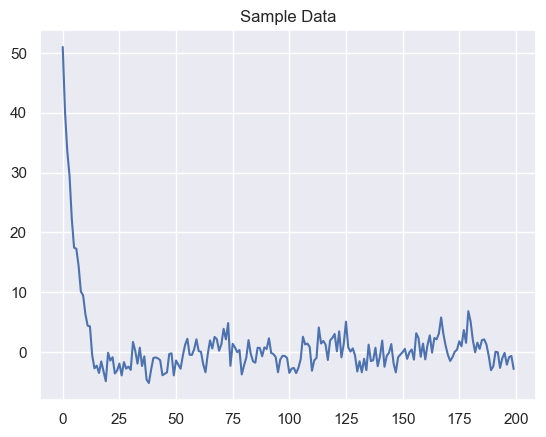

In [7]:
plt.plot(X)
plt.title("Sample Data")
plt.show()

self.phi_=array([0.79061609])
AR R2=0.902
self.theta_=array([-0.31164376])
MA R2=0.092
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  140
Model:                 ARIMA(1, 0, 1)   Log Likelihood                -333.832
Date:                Sun, 16 Mar 2025   AIC                            673.663
Time:                        04:49:14   BIC                            682.488
Sample:                             0   HQIC                           677.250
                                - 140                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9965      0.003    288.968      0.000       0.990       1.003
ma.L1         -0.0360      0.062     -0.581 

c:\Users\Roey\anaconda3\envs\advanced_ml\lib\site-packages\statsmodels\tsa\statespace\representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['alpha']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


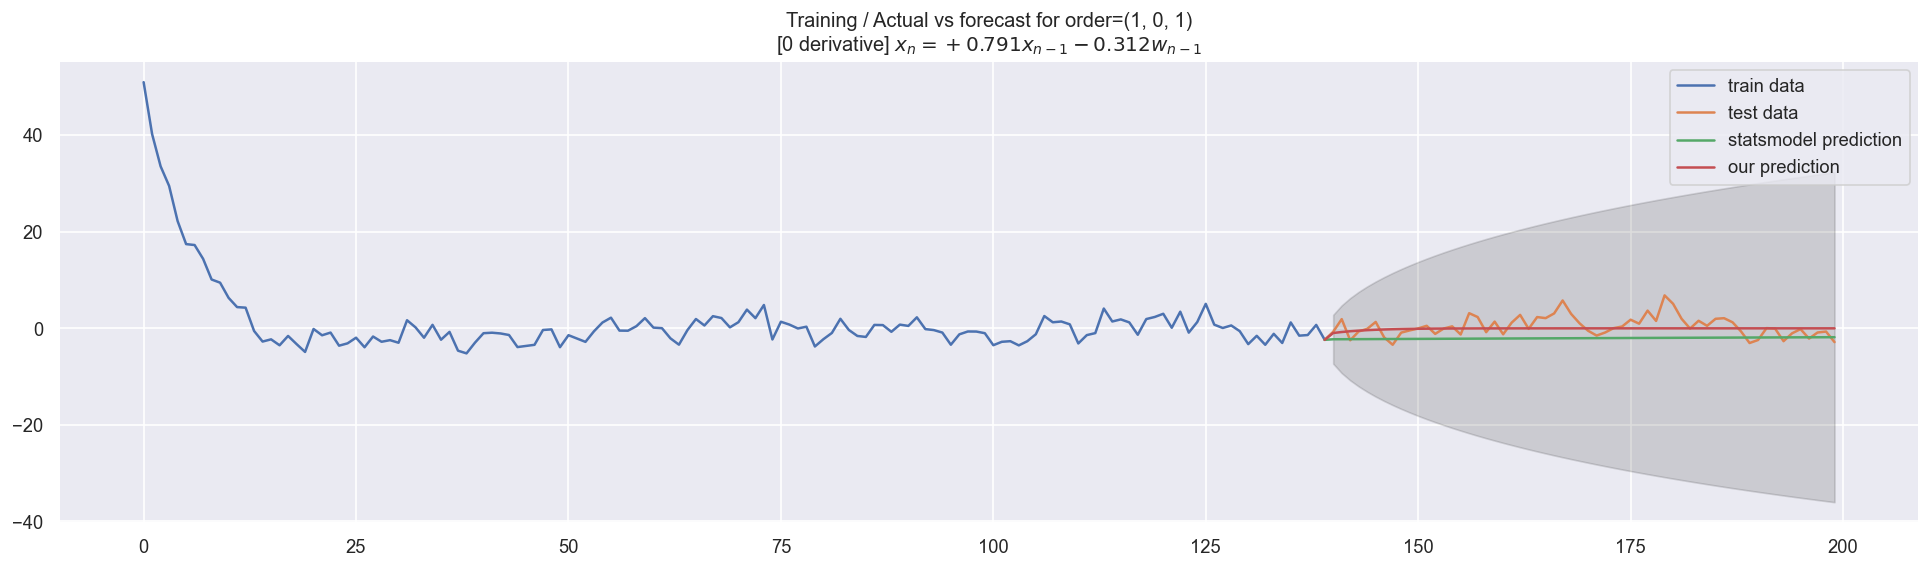

In [8]:
params = {"order": (1, 0, 1), "train_rate": 0.7, "verbose": True}

run_arima_train_test(X, params)

The model surprisingly struggles with the sample data. We expected it to fit the data nearly perfectly since the number of parameters is very small (2) and our sample data has small noises relative to the initial value.

Our model succeeded to predict $\phi_1$ (0.786 compared to the GT 0.8) and $\theta_1$ well (-0.313 compared the GT -0.3). The library's ARIMA implementation missed the parameters (0.997, -0.067) but got a very close result somehow, which is also unexpected.

It should be noted, however, that our model predicts rather well if we don't consider the noise (which is by definition impossible to predict).

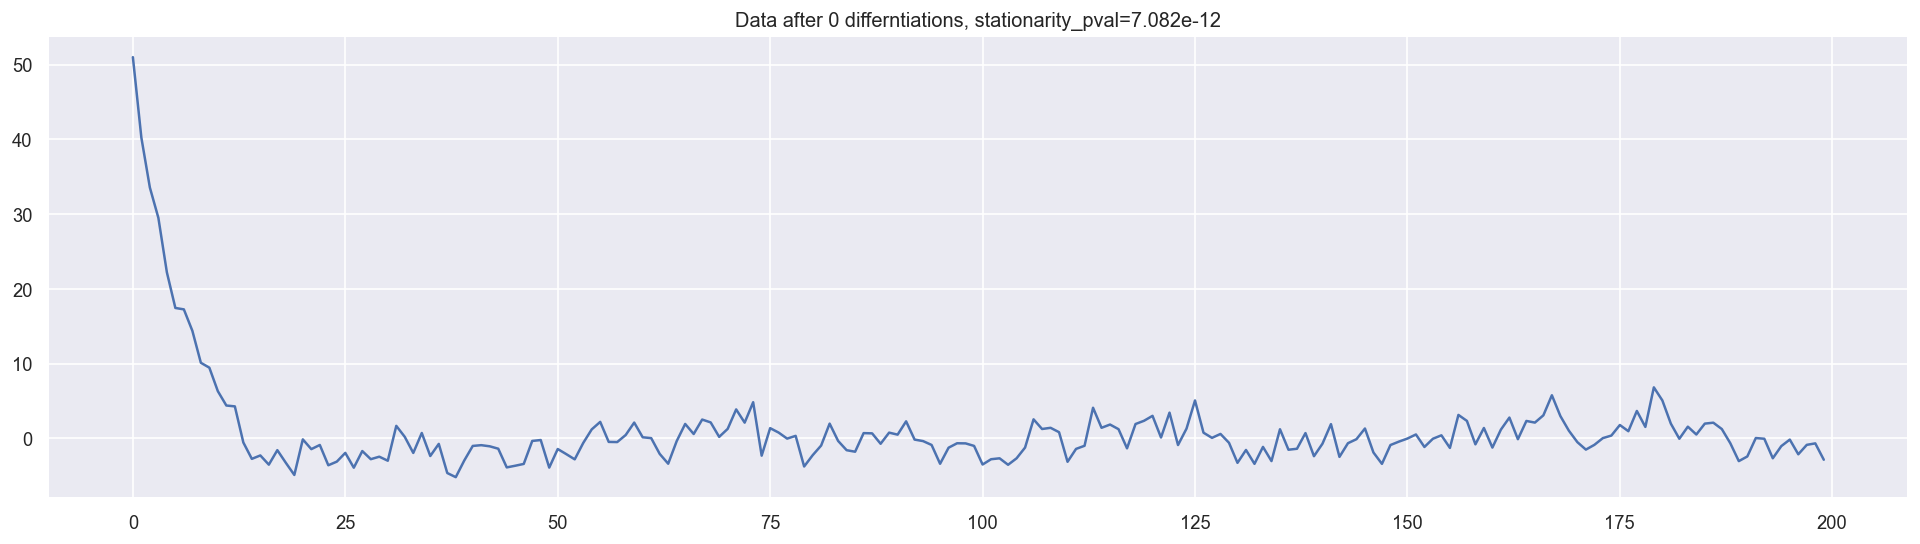

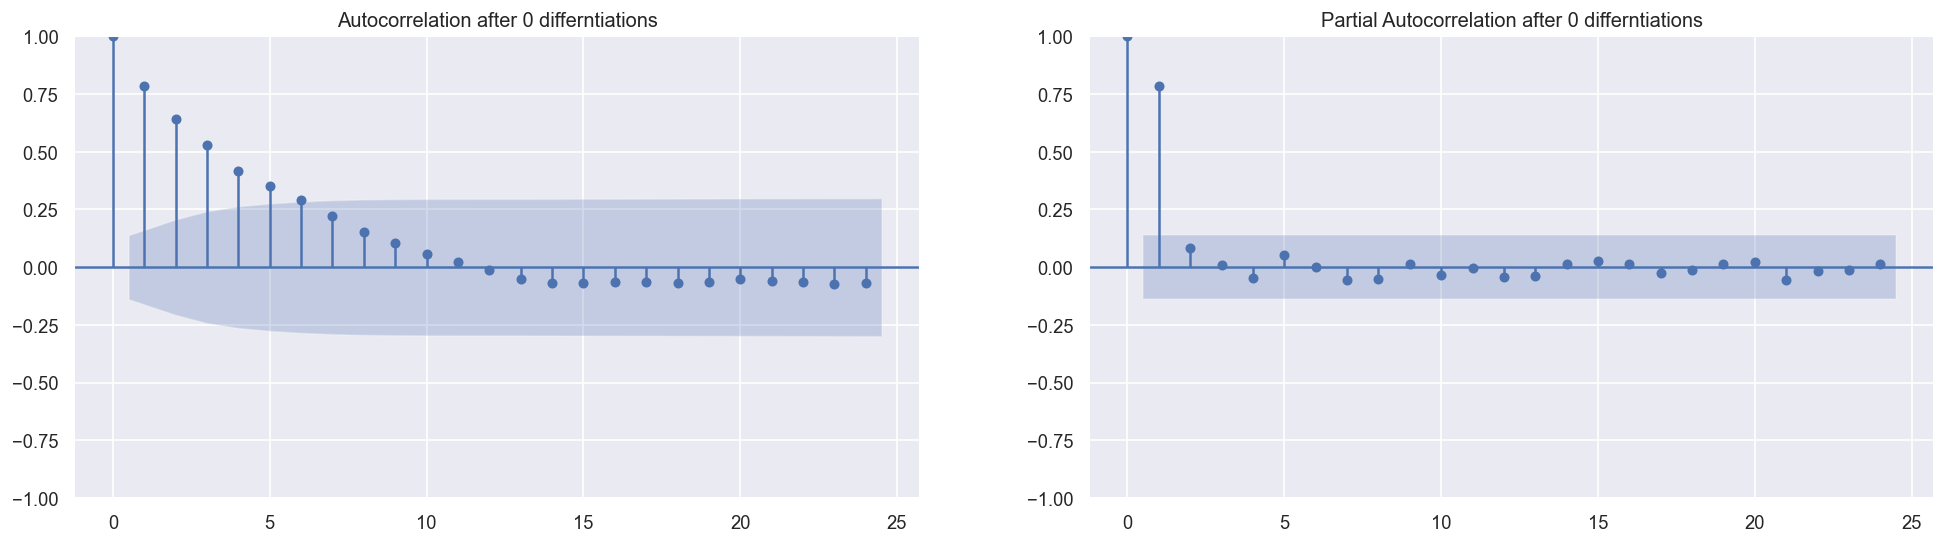

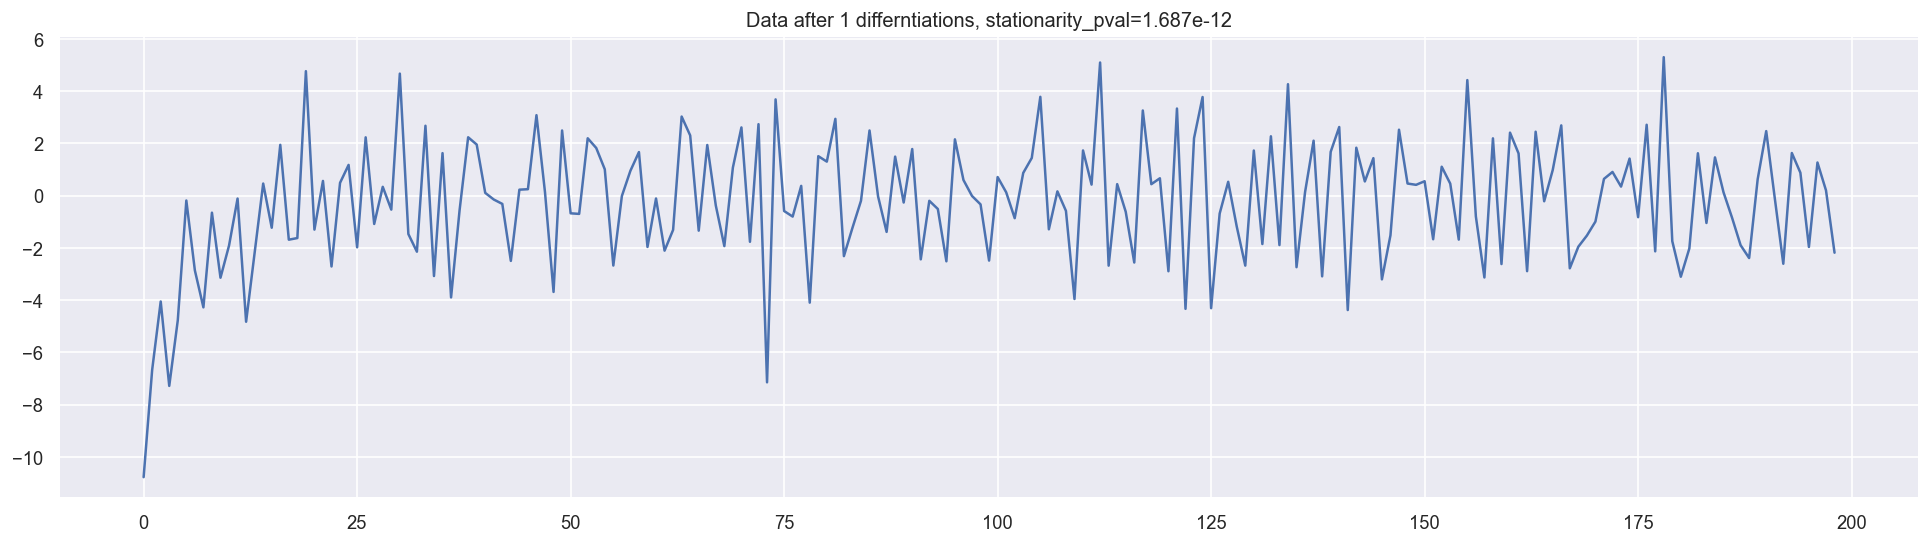

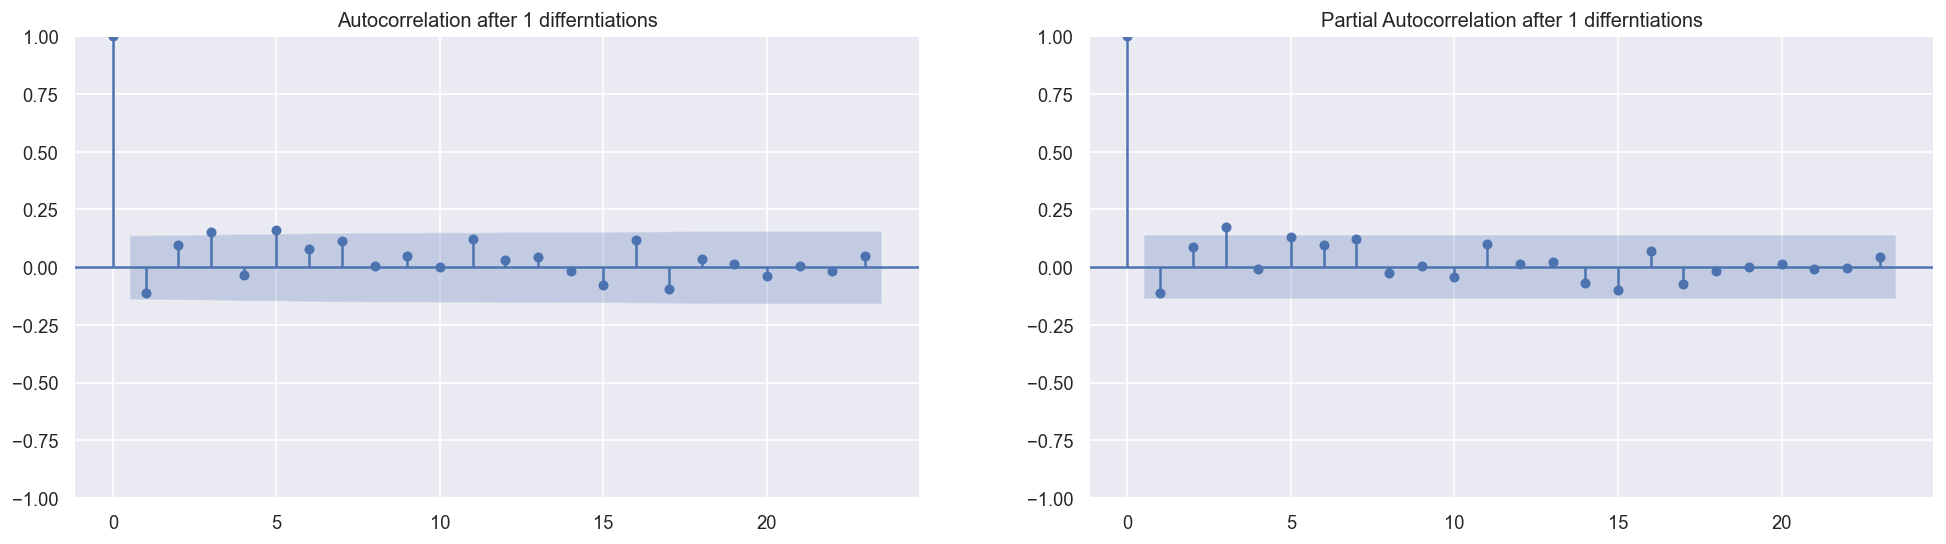

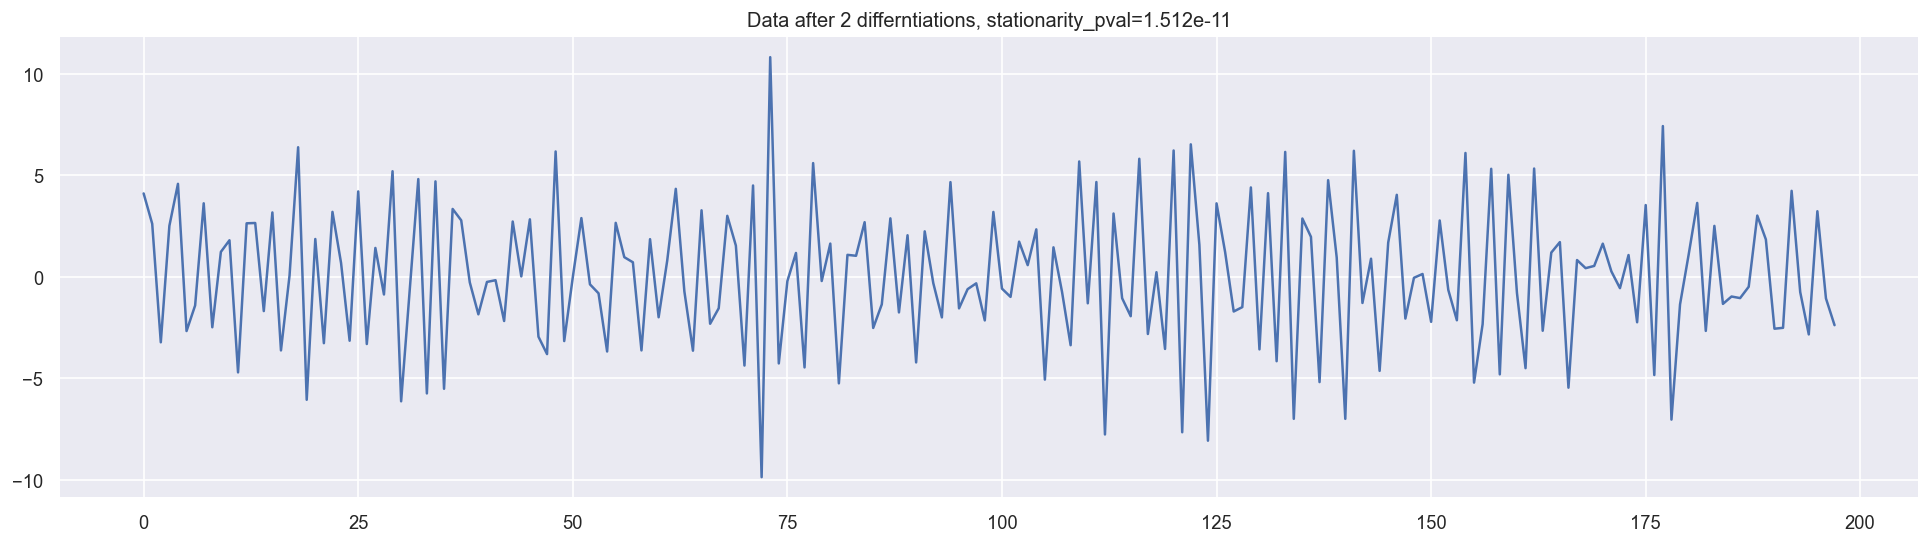

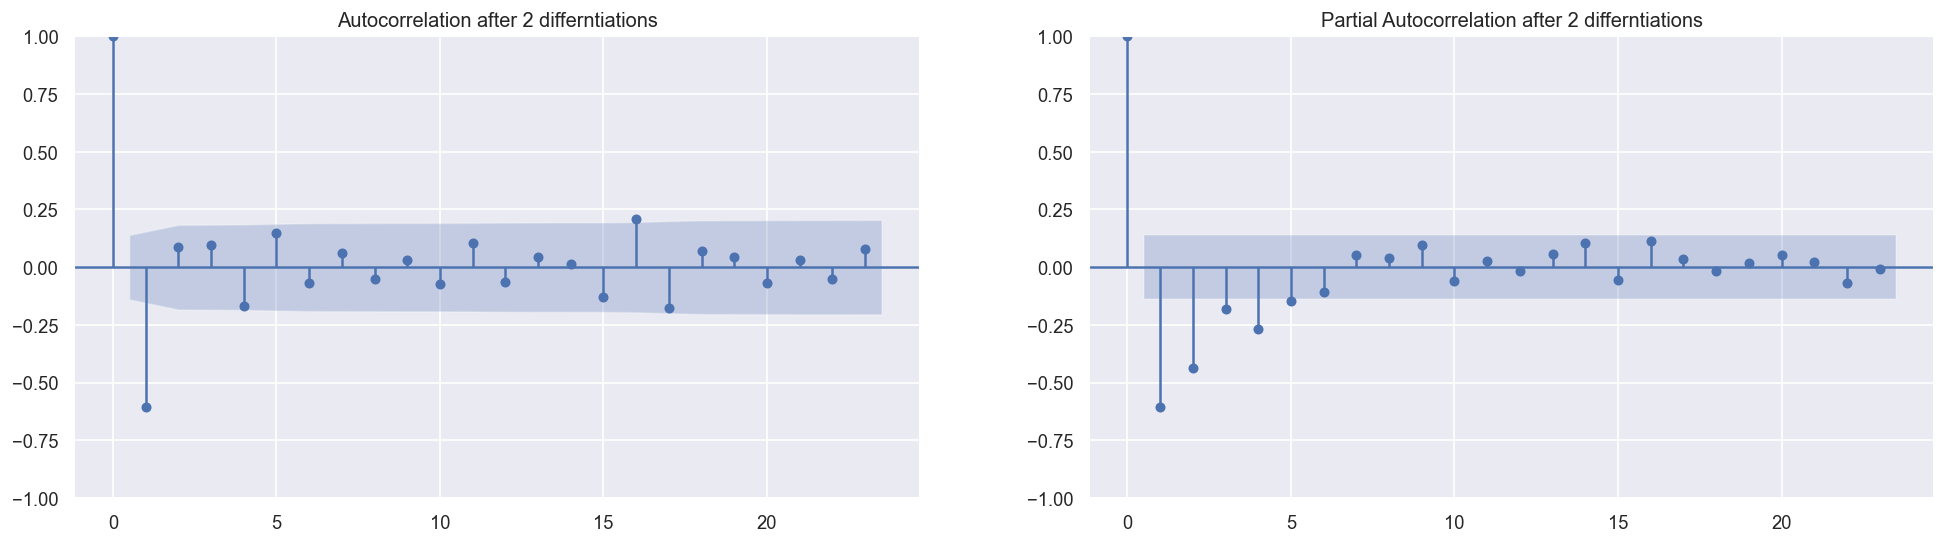

In [9]:
plot_correlation_graphs(X)

The high ACF values that we got for lags between 2 to 7 surprised us since we did not expect them to occur (we created the data to fit ARIMA(1,0,1)). Lets see what happens if we change to (1,0,7):

self.phi_=array([0.79061609])
AR R2=0.902
self.theta_=array([ 0.15916176,  0.06212602,  0.07969245, -0.12937399, -0.06705028,
       -0.1141146 , -0.36673522])
MA R2=0.159
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  140
Model:                 ARIMA(1, 0, 7)   Log Likelihood                -323.092
Date:                Sun, 16 Mar 2025   AIC                            664.183
Time:                        04:49:18   BIC                            690.658
Sample:                             0   HQIC                           674.942
                                - 140                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9918      0.013     7

c:\Users\Roey\anaconda3\envs\advanced_ml\lib\site-packages\statsmodels\tsa\statespace\representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['alpha']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


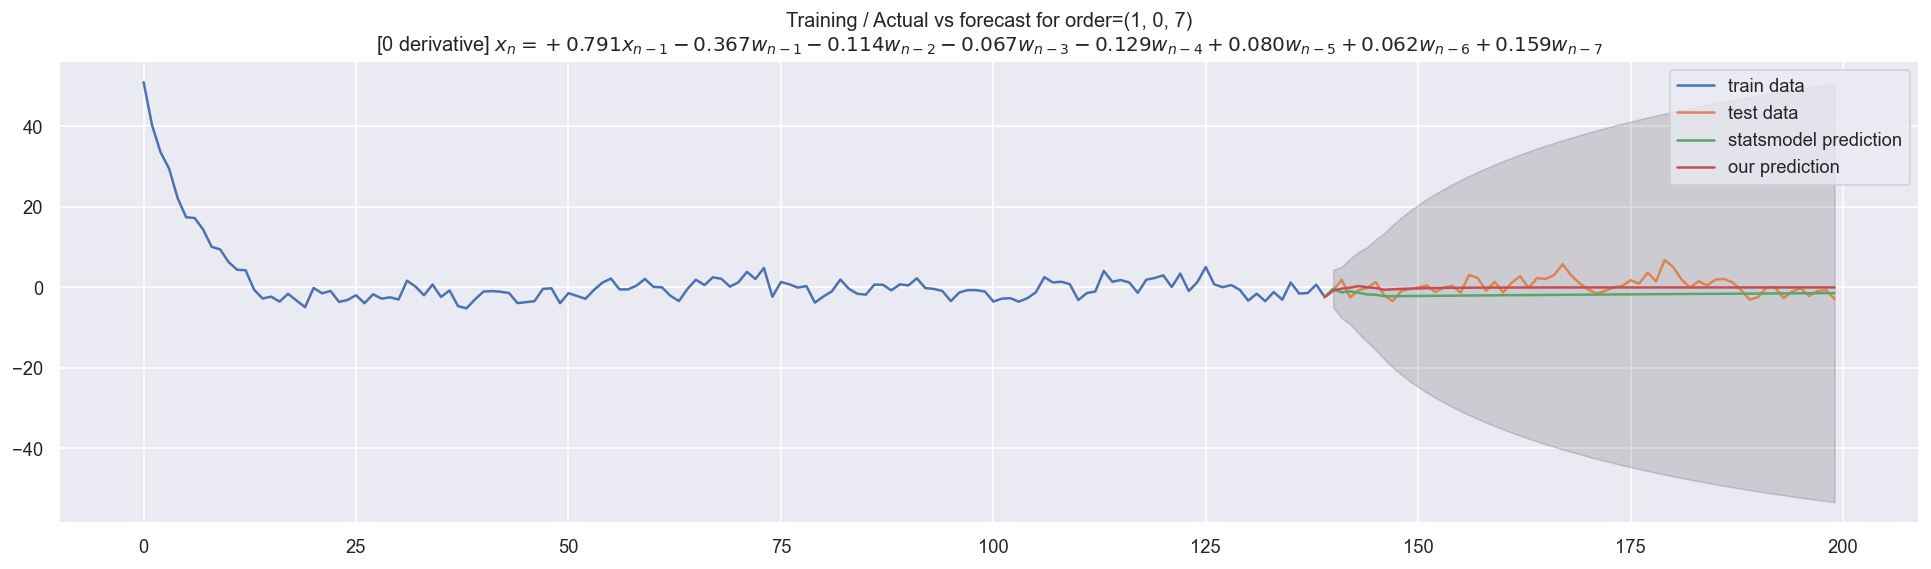

In [10]:
params = {"order": (1, 0, 7), "train_rate": 0.7, "verbose": True}

run_arima_train_test(X, params)

Did not appear to make much a difference...

# ARIMA demonstration

Demonstrate your ARIMA implementation.

Add plots and figures.

Please use the cell below to describe your results and tests.

Describe the difference between your implementation and the statsmodels implementation. Hint: you can look at the documentation.


In order to demonstrate the ARIMA implementation, we configured the following graphs and plots:

The first graphs sections focused on the stationarity and the correlation between the value, without making forecasts

1. A simple graph of the original dataset with the "date" as X-axis and "value" as Y-axis
2. Auto-correlation (ACF) graph of the original dataset - ACF is a method to find a correlation different time lags. This method seperates the data into time lags. The X-axis is the lag size and the Y-axis is the lag correlation.
   - 1 suggests a strong positive correlation (Increase with the same trend)
   - -1 suggests a strong negative correlation (Decrease after increase and vice versa)
   - 0 suggests no correlation at all
3. Partial auto-correlation (PACF) graph of the original dataset - PACF is similar to ACF but measures correlation to the **direct** influence of lag T while ignoring the other lags' contribution to the correlation.
4. In addition, we include graphs of the 1st and 2nd derivatives of the original dataset, including their ACF and PACF graphs. That helps us to measure the stationarity between the values in the graph and the correlation between them.
5. We use Augmented Dickey–Fuller test to show stationarity of the data

The second part includes a forecasting of the original dataset values as a function of the time units, but with some additions:
1. The left part of the graph contains the first X% part of the dataset as it's original values (Train set). This data part is being fitted by the model.
2. The right part of the graph contains the remaining (100-X)% part of the dataset with both it's original values (Test set) and its forecast values: One forecast by our ARIMA model and the other by the statslib ARIMA model.
3. The forecast values are also covered by a gray area which indicates the lower and upper standard confidence interval of the forecasted value (given by the library). If the forecast is done well, the true value of the test set should be inside that area.


# AMZN Dataset


We used the stock information of Amazon directly using the Yahoo Finance package. We did not use the static file provided in the exercise in order to get the maximum snapshot (not only until 2022), and made the following preprocess:

1. The "Date" field was in ISO format "YYYY-MM-DD hh:mm:ss.ms" and we converted it just to YYYY-MM-DD
2. We measured on the column "Closed", which according to what we read on the site - is the price that the stock was closed on at the end of the business day - the most interesting value. There is no need to look at other columns since they are highly correlative but represent less interesting data in the real world.
3. While printing the X-values in the graphs, in order to make it clean to read, we printed just yearly timestamps (We took the first commerce day of a fiscal year as an X label) + The first and last values

We tested the performance on several p,d,q combinations


In [11]:
ticker = yf.Ticker("AMZN")

amzn_dataset_original = ticker.history(period="max").reset_index()
amzn_dataset_original["Date"] = amzn_dataset_original["Date"].astype(str)
amzn_dataset_original["Date"] = amzn_dataset_original["Date"].str.split().str[0]

amzn_dataset_original.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,1997-05-15,0.121875,0.125000,0.096354,0.097917,1443120000,0.0,0.0
1,1997-05-16,0.098438,0.098958,0.085417,0.086458,294000000,0.0,0.0
2,1997-05-19,0.088021,0.088542,0.081250,0.085417,122136000,0.0,0.0
3,1997-05-20,0.086458,0.087500,0.081771,0.081771,109344000,0.0,0.0
4,1997-05-21,0.081771,0.082292,0.068750,0.071354,377064000,0.0,0.0


In [12]:
dataset = amzn_dataset_original[["Date", "Close"]]

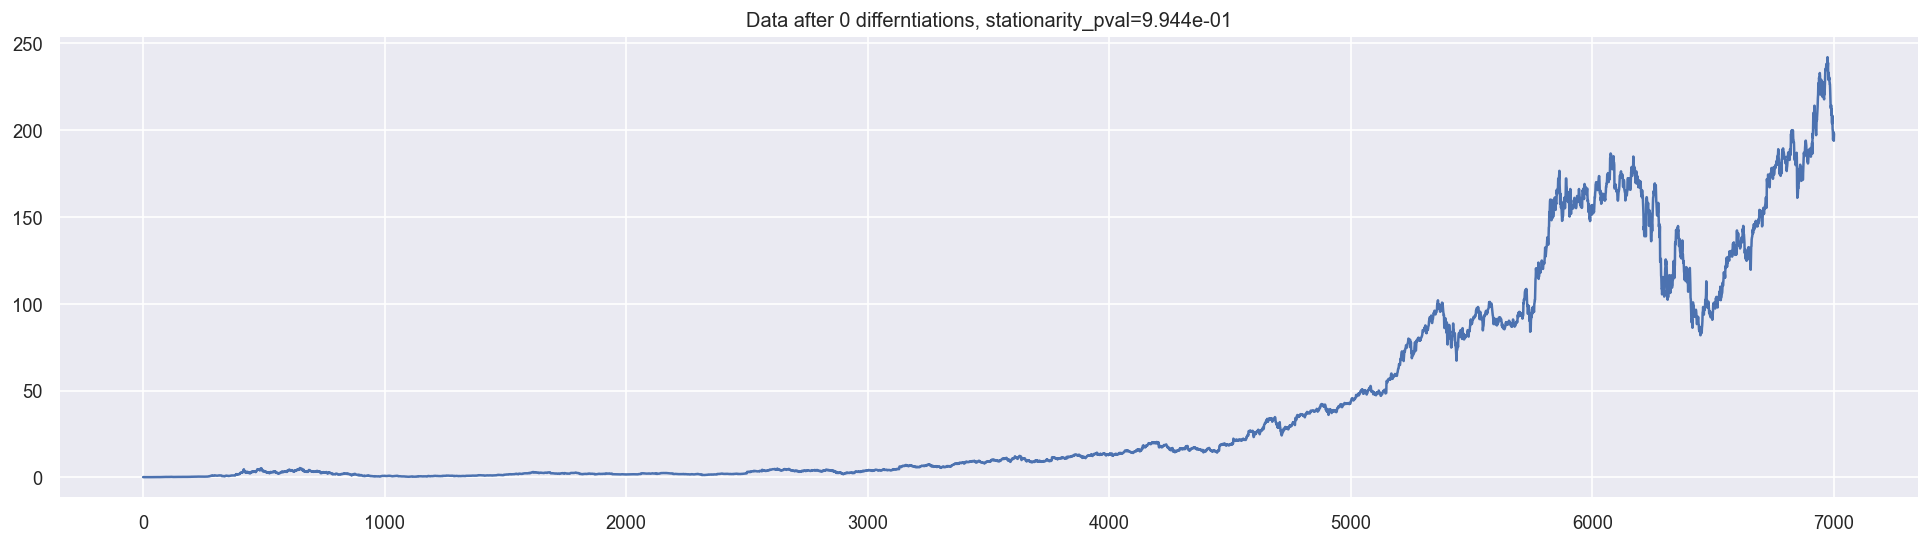

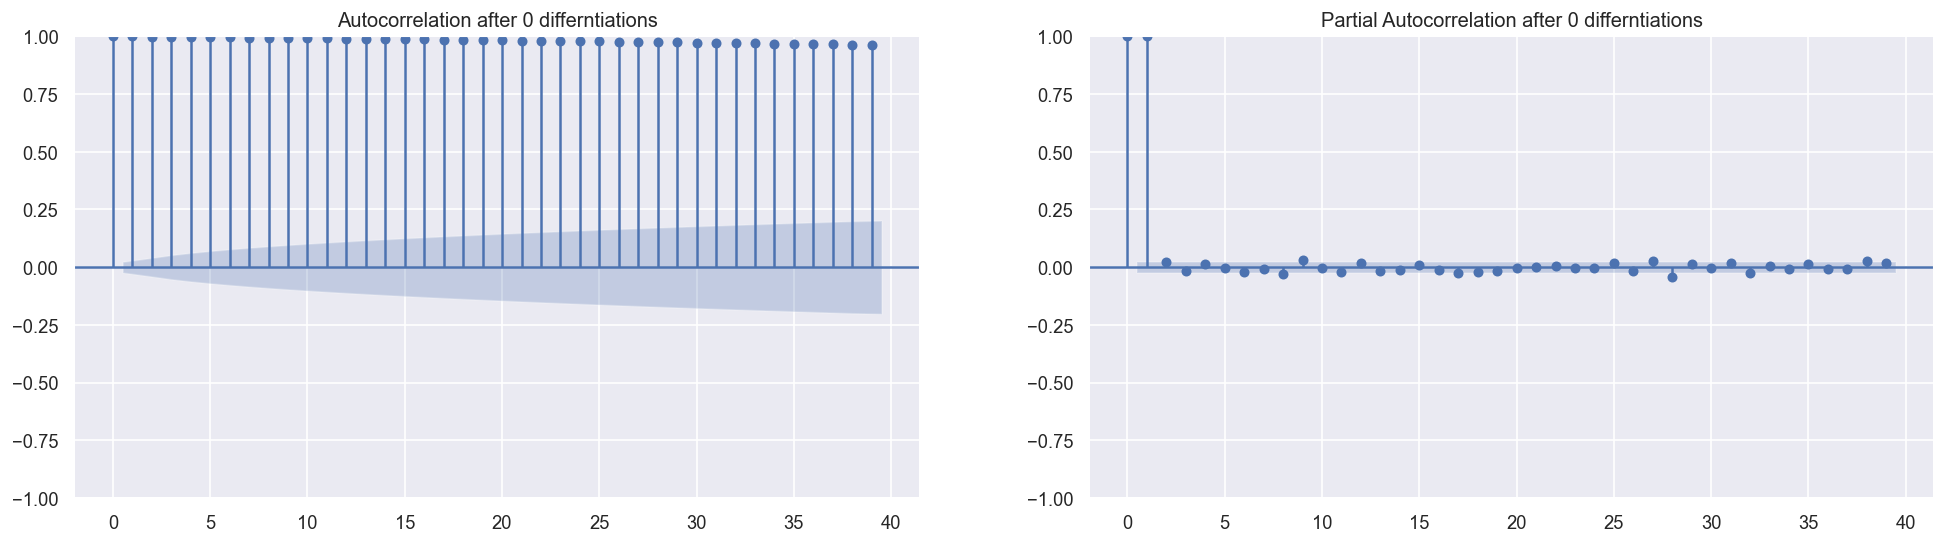

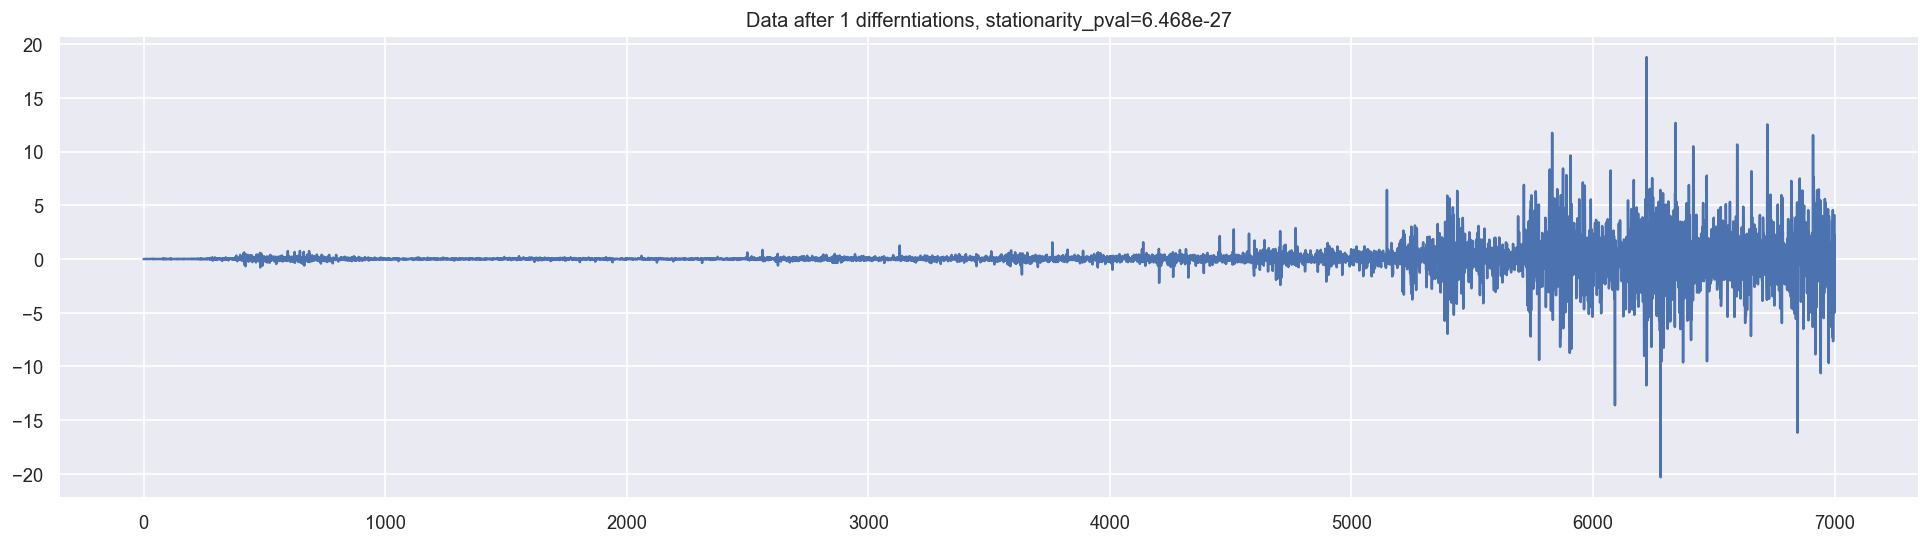

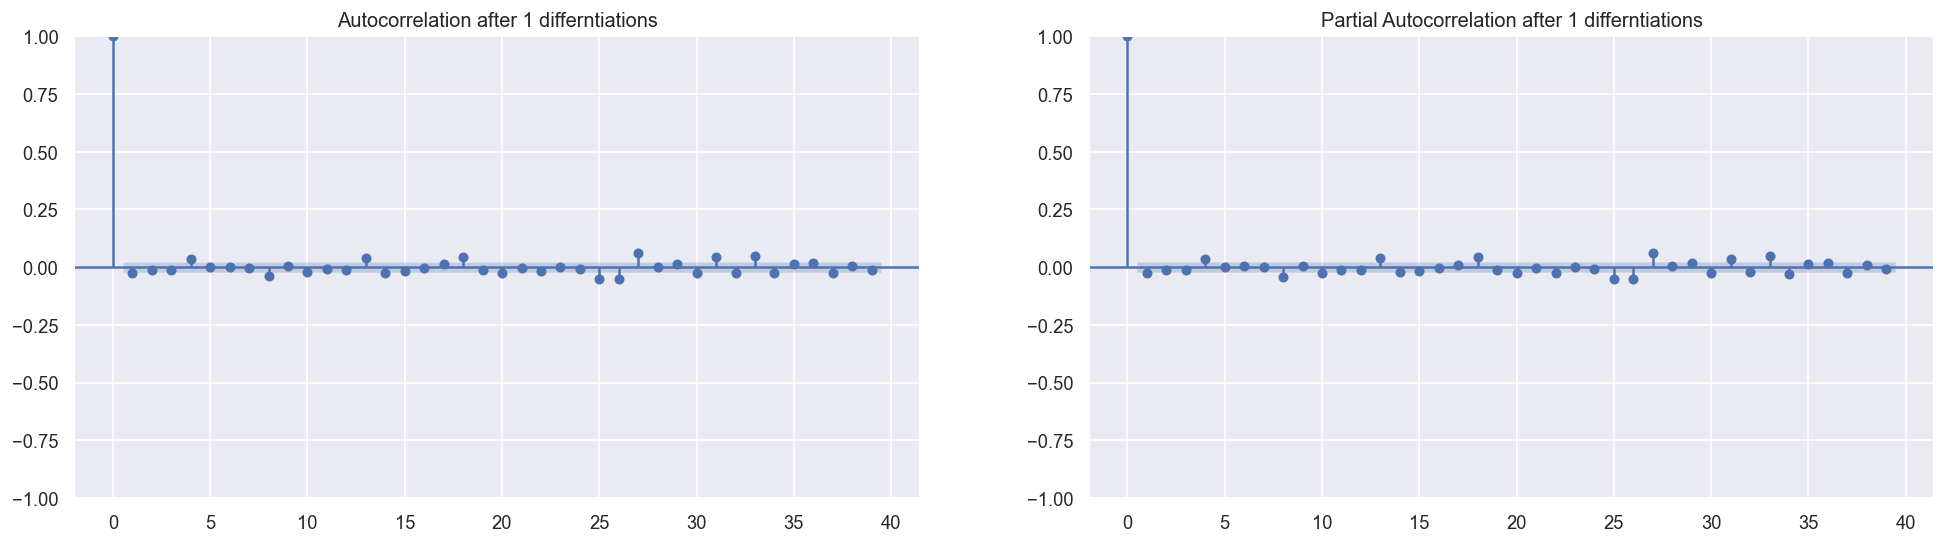

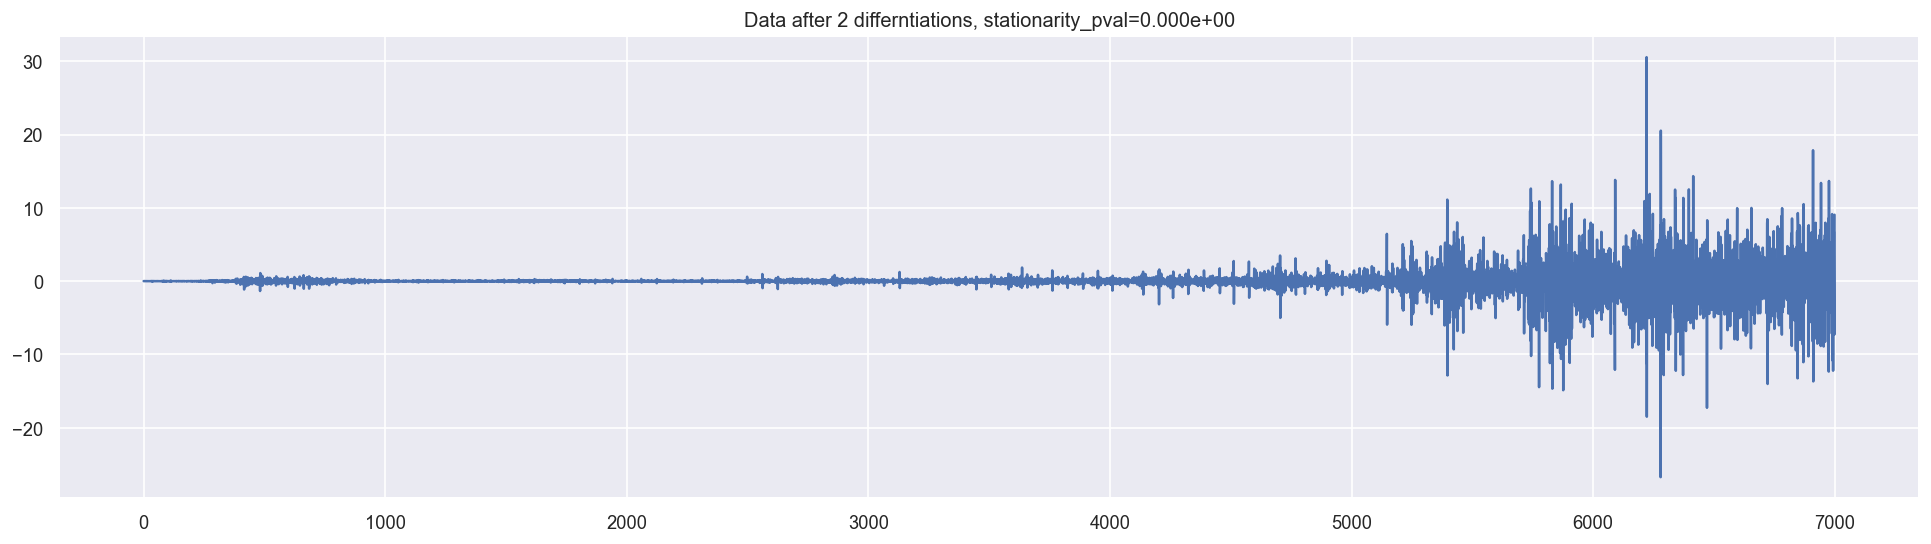

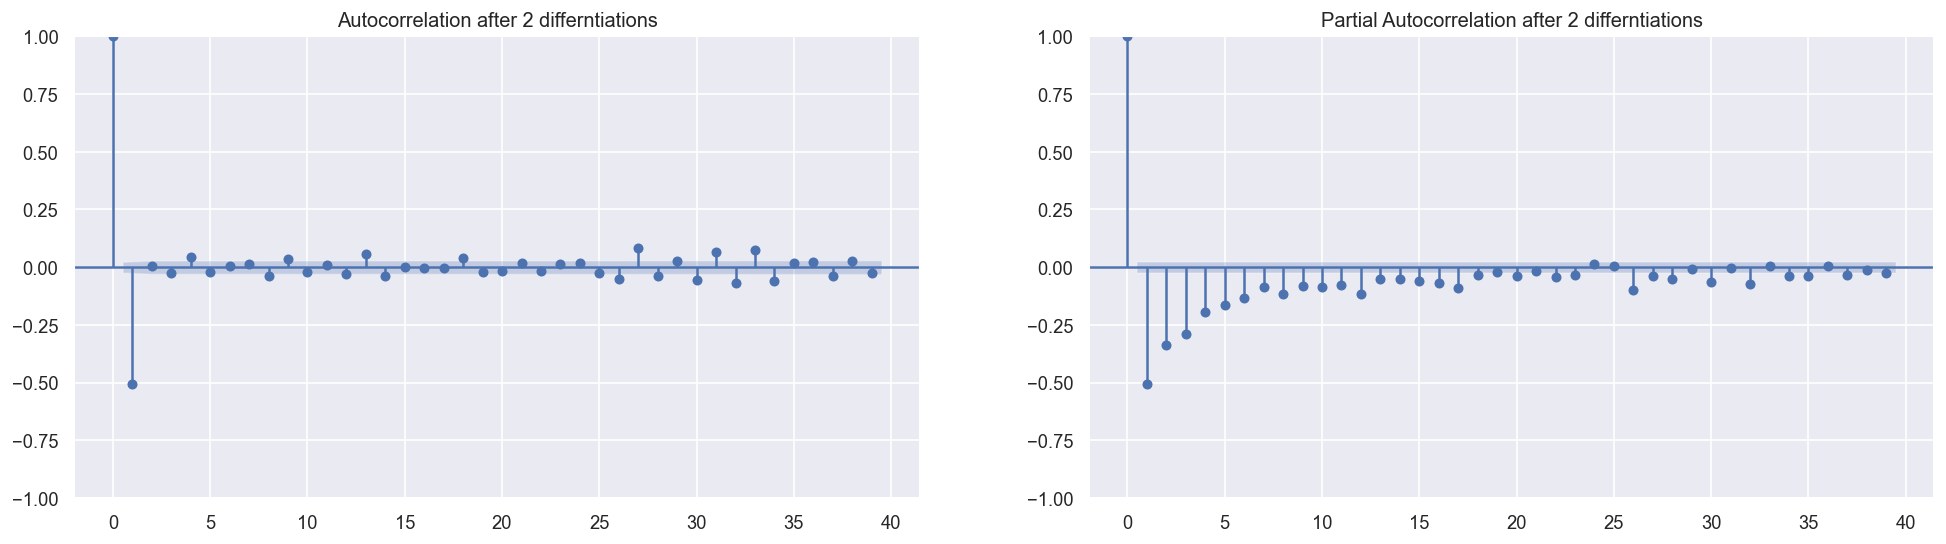

In [13]:
plot_correlation_graphs(dataset["Close"])

# Experiments and Analysis + Results

ADF test shows that we should derive the data once to achieve stationarity.

At d=0 PACF strongly suggests that we should take p=1, and the ACF suggests that there is a huge correlation with every value, which makes sense since there is an obvious trend in the data.

At d=1 there is no significance ACF/PACF value at any lag (except the trivial). So we assume the model will stay close to constant +some small trend since we derived once.

At d=2 there some correlation at q=1 but the PACF decreases slowly. We will try to take a large p and see what happens.

Train / Test based on:
order -> (1, 0, 1)
train_rate -> 0.8
verbose -> True
self.phi_=array([1.00076274])
AR R2=0.999
self.theta_=array([-0.01408177])
MA R2=0.000


c:\Users\Roey\anaconda3\envs\advanced_ml\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'


                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 5601
Model:                 ARIMA(1, 0, 1)   Log Likelihood               -4315.589
Date:                Sun, 16 Mar 2025   AIC                           8637.178
Time:                        04:49:25   BIC                           8657.070
Sample:                             0   HQIC                          8644.110
                               - 5601                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.0000   5.95e-05   1.68e+04      0.000       1.000       1.000
ma.L1         -0.0126      0.003     -3.802      0.000      -0.019      -0.006
sigma2         0.2729      0.001    242.930      0.0

c:\Users\Roey\anaconda3\envs\advanced_ml\lib\site-packages\statsmodels\tsa\statespace\representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['alpha']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


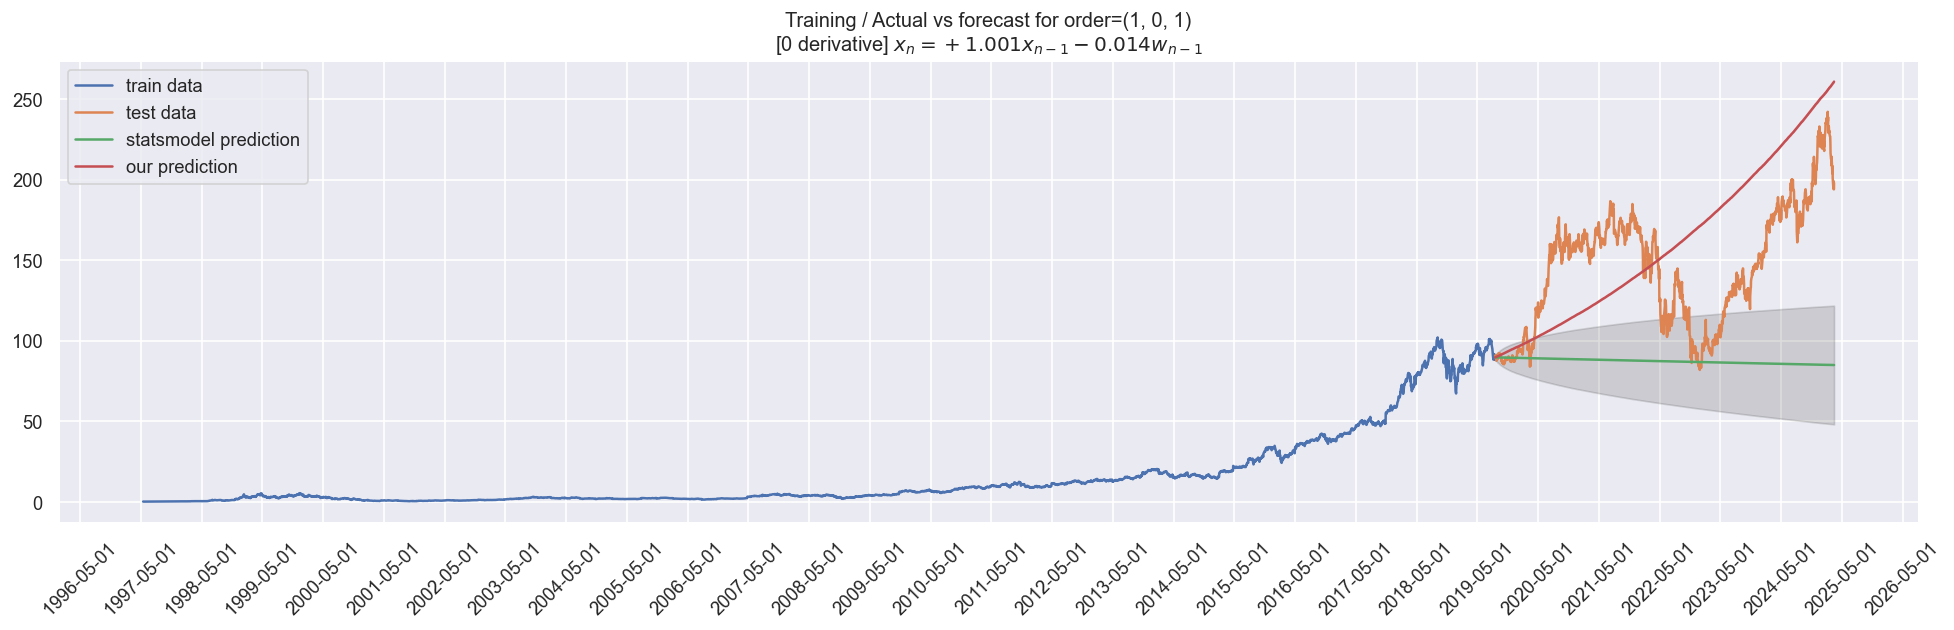

Train / Test based on:
order -> (1, 1, 1)
train_rate -> 0.8
verbose -> True
self.phi_=array([-0.01169935])
AR R2=-0.001
self.theta_=array([-0.00043216])
MA R2=-0.001
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 5601
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -4306.872
Date:                Sun, 16 Mar 2025   AIC                           8619.745
Time:                        04:49:27   BIC                           8639.637
Sample:                             0   HQIC                          8626.677
                               - 5601                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8128      0.037     21.966 

c:\Users\Roey\anaconda3\envs\advanced_ml\lib\site-packages\statsmodels\tsa\statespace\representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['alpha']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


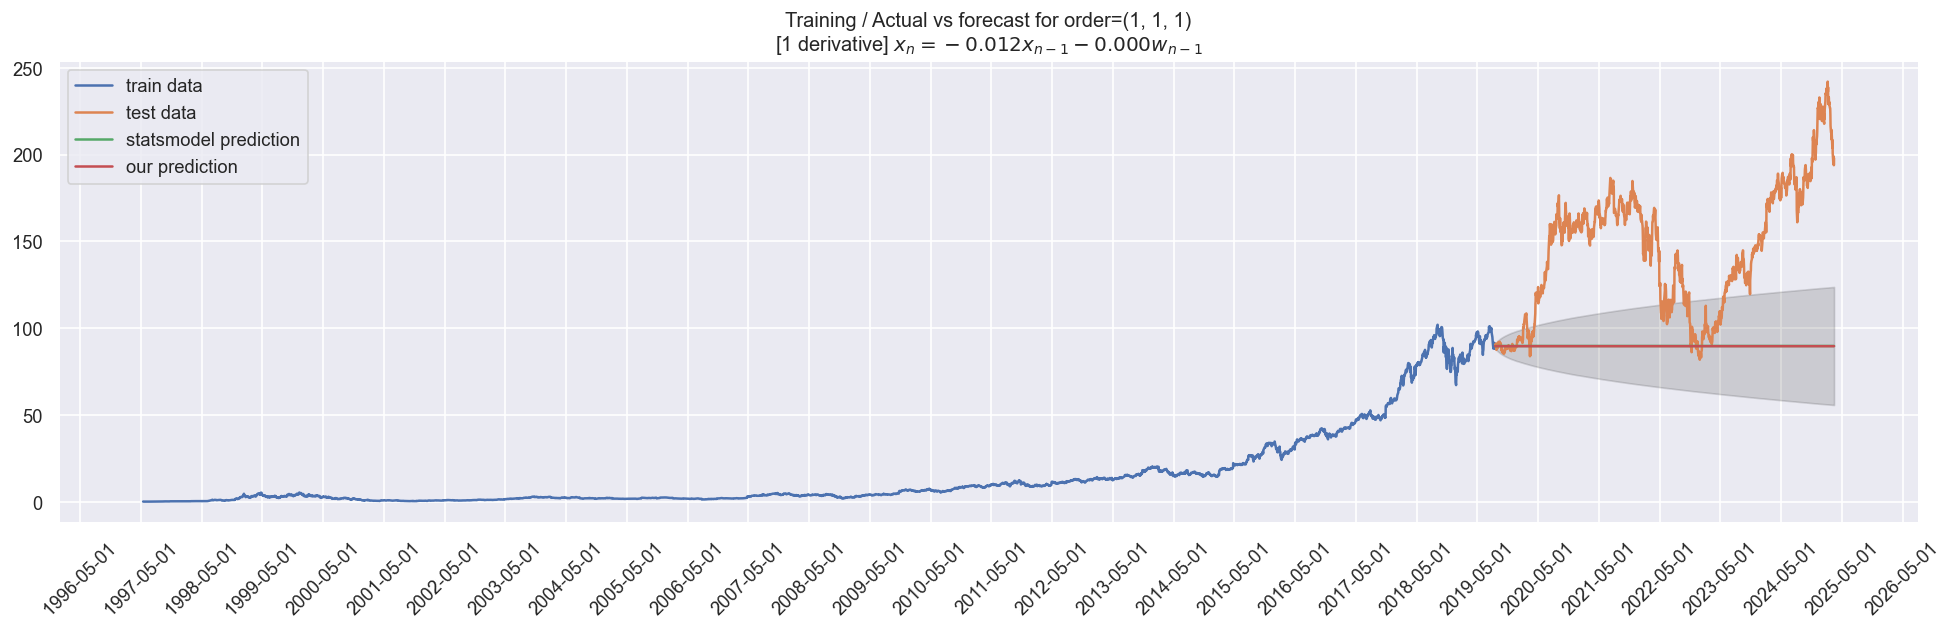

Train / Test based on:
order -> (7, 1, 7)
train_rate -> 0.8
verbose -> True
self.phi_=array([-0.01631784, -0.01086655,  0.0524915 , -0.01611318, -0.00591278,
       -0.03647301, -0.01136005])
AR R2=0.004
self.theta_=array([-0.00248203, -0.00028724,  0.00035796, -0.00227542,  0.00391122,
       -0.00084865, -0.00130581])
MA R2=-0.001


c:\Users\Roey\anaconda3\envs\advanced_ml\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 5601
Model:                 ARIMA(7, 1, 7)   Log Likelihood               -4256.888
Date:                Sun, 16 Mar 2025   AIC                           8543.776
Time:                        04:49:39   BIC                           8643.234
Sample:                             0   HQIC                          8578.435
                               - 5601                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0754      0.811     -0.093      0.926      -1.665       1.514
ar.L2         -0.1068      0.443     -0.241      0.810      -0.975       0.762
ar.L3         -0.2344      0.312     -0.752      0.4

c:\Users\Roey\anaconda3\envs\advanced_ml\lib\site-packages\statsmodels\tsa\statespace\representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['alpha']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


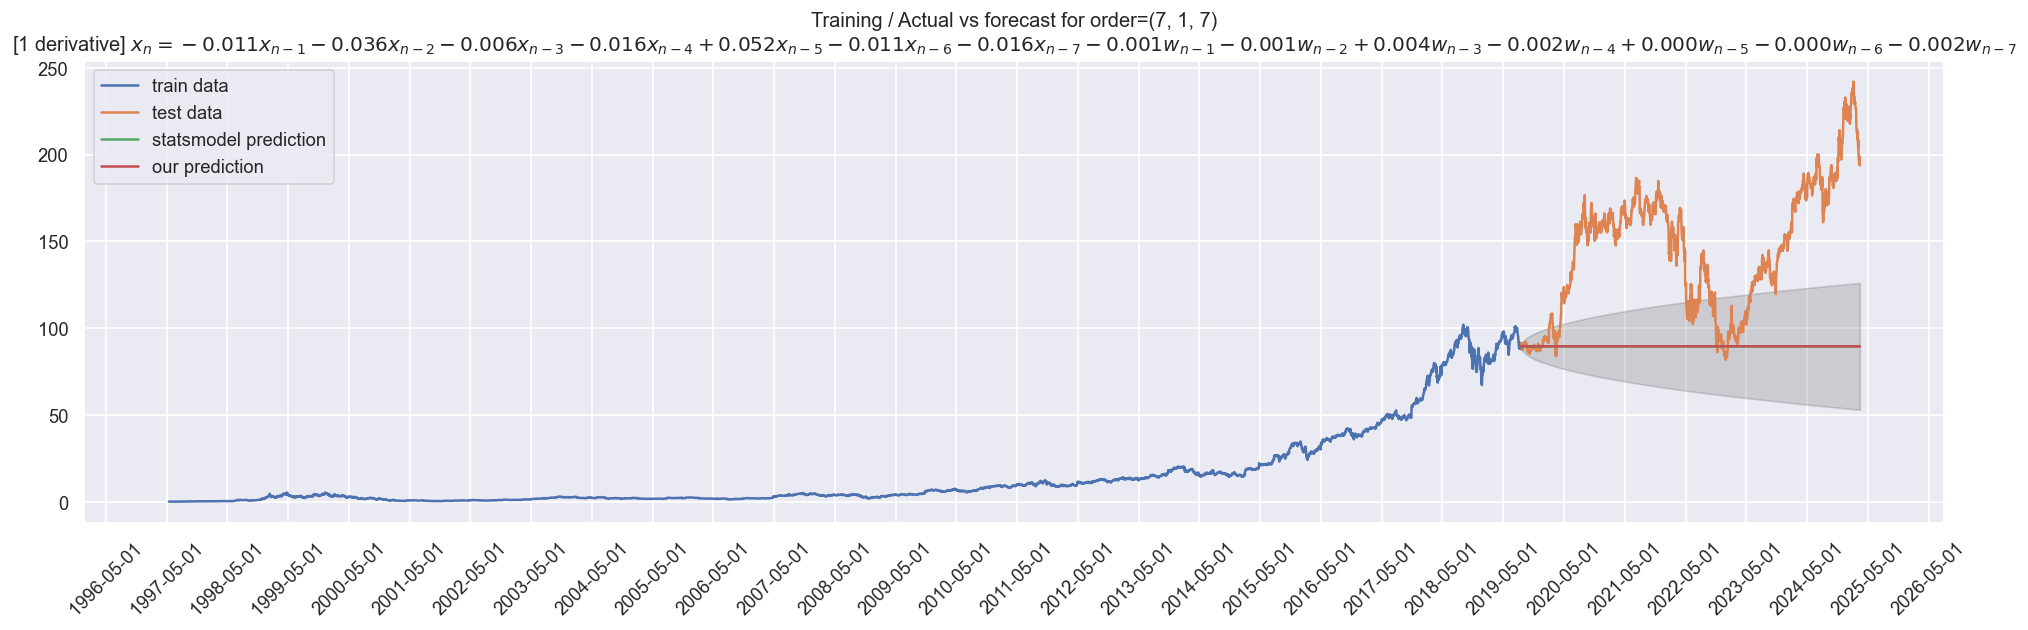

Train / Test based on:
order -> (10, 2, 1)
train_rate -> 0.8
verbose -> True
self.phi_=array([-0.07240675, -0.15885408, -0.27307372, -0.2973099 , -0.38596035,
       -0.47322044, -0.63170233, -0.71990013, -0.83029346, -0.90160431])
AR R2=0.455
self.theta_=array([-0.00783014])
MA R2=0.000
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 5601
Model:                ARIMA(10, 2, 1)   Log Likelihood               -4273.710
Date:                Sun, 16 Mar 2025   AIC                           8571.420
Time:                        04:49:46   BIC                           8650.984
Sample:                             0   HQIC                          8599.147
                               - 5601                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]


c:\Users\Roey\anaconda3\envs\advanced_ml\lib\site-packages\statsmodels\tsa\statespace\representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['alpha']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


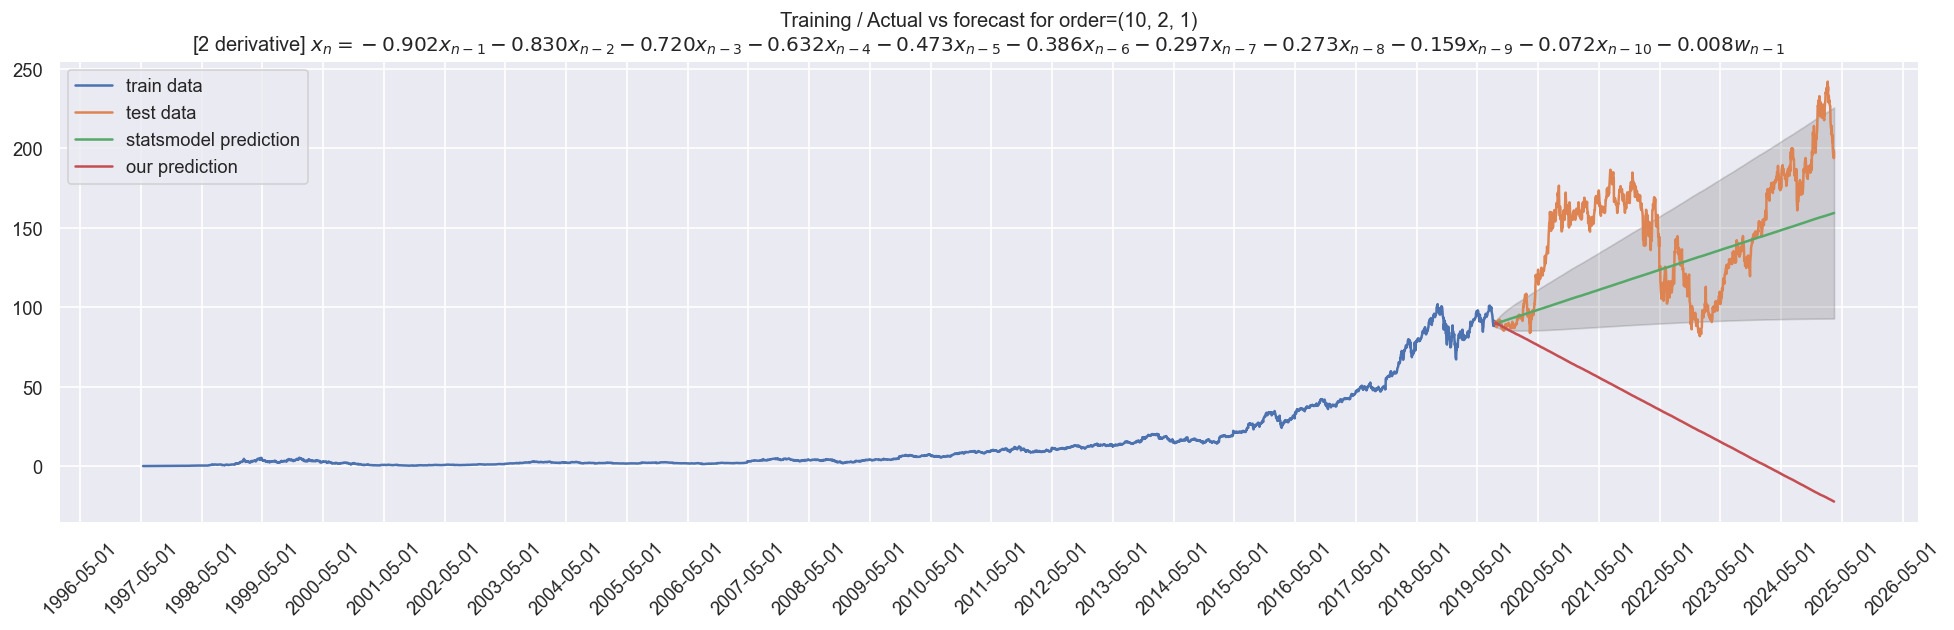

Train / Test based on:
order -> (None, None, None)
train_rate -> 0.8
verbose -> True
p_val=2.292380211290281e-21
d=1
p=1
pacf=[ 1.00000000e+00 -1.26363309e-02 -3.79112666e-02 -8.67817845e-03
 -1.68342760e-02  5.15253198e-02 -1.14427553e-02 -1.70677719e-02
 -8.16258247e-02 -4.99997110e-04 -2.58119646e-02 -4.18534114e-02
  2.22108567e-03  5.00830021e-02 -6.31132068e-02  2.02083600e-02
  3.29880351e-02  6.82880775e-02  5.52396943e-02 -2.29970255e-04
 -3.65535829e-02 -4.12198966e-02 -2.01604235e-02  6.90944907e-02
 -3.67603275e-02 -8.25820988e-03  4.08915293e-02 -4.67501737e-03
  3.64005485e-02 -5.47966185e-02 -3.66258611e-02 -7.34937069e-03
  6.13390561e-02  4.54216019e-02 -1.15261945e-02 -2.40444518e-02
  2.45553102e-02 -3.82166716e-03]
q=1
acf=[ 1.00000000e+00 -1.26340744e-02 -3.77320557e-02 -7.68609540e-03
 -1.51469759e-02  5.24299172e-02 -1.14552691e-02 -2.03982757e-02
 -8.02822392e-02  1.54766000e-03 -1.60596799e-02 -4.05503120e-02
  5.88182306e-03  4.47679226e-02 -5.99988626e-02  2.

c:\Users\Roey\anaconda3\envs\advanced_ml\lib\site-packages\statsmodels\tsa\statespace\representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['alpha']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


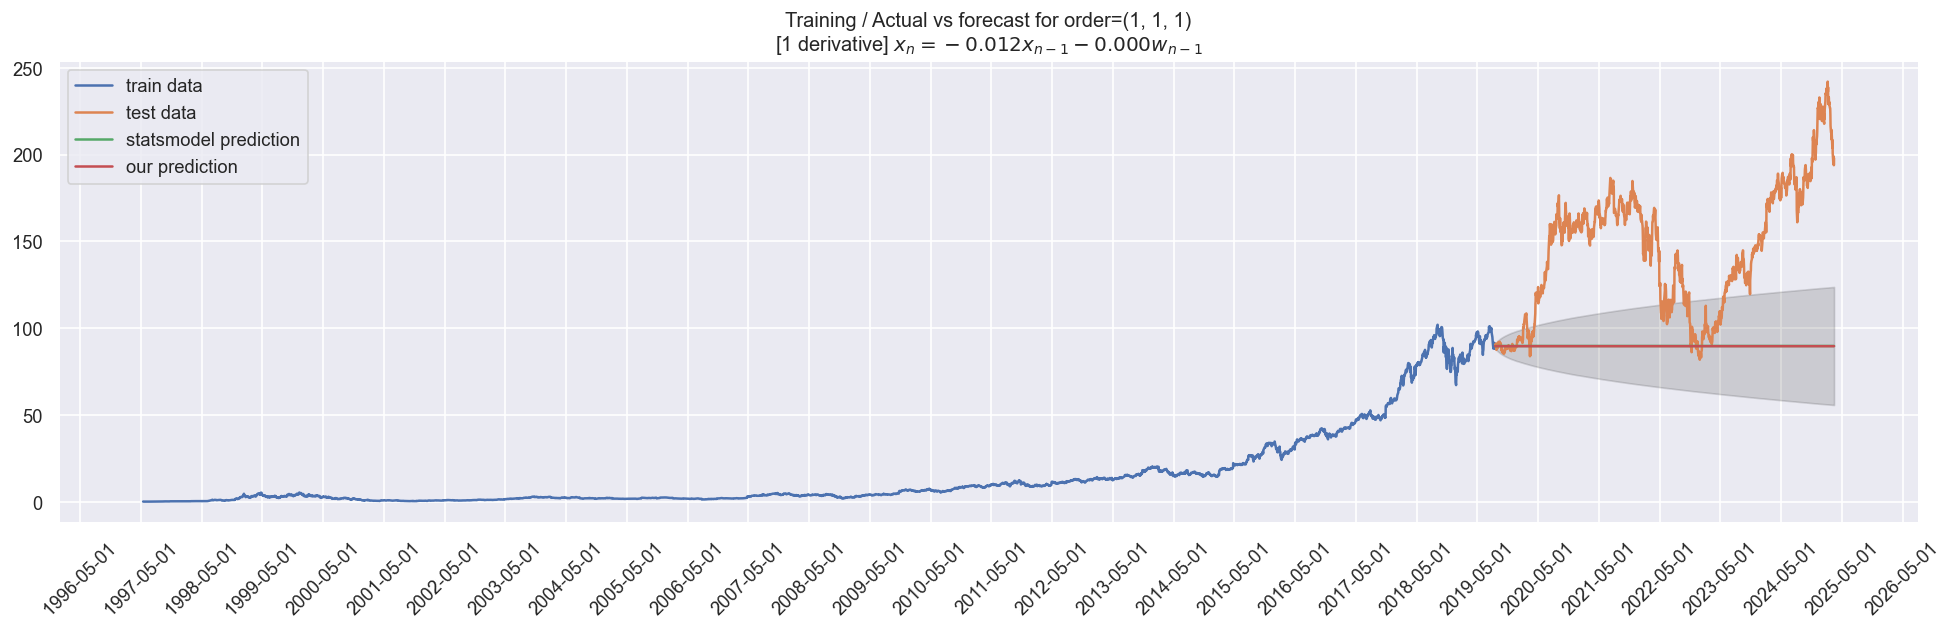

In [ ]:
hyperparams = [
    {"order": (1, 0, 1), "train_rate": 0.8, "verbose": False},
    {"order": (1, 1, 1), "train_rate": 0.8, "verbose": False},
    {"order": (7, 1, 7), "train_rate": 0.8, "verbose": False},
    {"order": (10, 2, 1), "train_rate": 0.8, "verbose": False},
    {"order": (None, None, None), "train_rate": 0.8, "verbose": False},  # Automatic fit
]

for hyperparam in hyperparams:
    print("Train / Test based on:")
    for k, v in hyperparam.items():
        print(f"{k} -> {v}")

    predicted_dataset = run_arima_train_test(
        dataset["Close"].values, hyperparam, dataset["Date"].values
    )

We've done a various of experiments and predictions using both the statsmodel Arima and the custom Arima
We found out the following measures:

1. When trying fitting the data without derivation the results were better than we expected, and our model performed better than the library.
2. The automatic fitting of (p,d,q) fit p=d=q=1 as we expected from the ACF/PACF graphs
3. The library implementation handled d=2 better than us. According to their documentation, the fit method is rather complicated while we use linear regression. At first, we considered this a bug in our part, but after deep diving into the code and lots of inspection we found out this actually makes sense since all of the correlations we found in the ACF/PACF were strictly negative so this is what the model has learned. The library implementation makes up for it by parameter fitting tricks (like weigting samples, likelihood estimation, etc). A good sanity check for us is that even when given q=4 (which is too large) it fits only the first one which can be seen in the expression in the graph title - the only one with correlation. So our conclusion on the matter is that they use some technique that we did not see in class, because a model using d=2 does not fit this case (which is d=1). Adding regularization to the linear regression did not seem to solve the problem so we stayed with it as is.
4. We do, however, predict "well-behaved" data the fits the theory. We learned that linear regression can take wild turns (like the "explosion" we saw) when the data we are trying to fit is not linear, and it may find fake trends.
5. We tried setting (p,d,q)=(7,1,7) in order to test our implementation's stability. This did not seem to change the results much, which makes sense since according to the ACF/PACF graphs there is no correlation that the model could have learned, so the model is indeed stable.
6. We learned that fitting time series data can be very tricky and senstive to parameters and noise, and even noises of small magnitudes can affect greatly. We thought our sample data is easy and it appeared to be challenging (for the library model more than to ours). Even when using the library implementation - its std error for the parameters estimation were huge.
7. We learned that a precise prediction of stocks is extremely hard - one cannot assume a defined model that will work over the years since the data shift in different periods and trends. This makes sense because if it was an easy task then everyone was doing that and was getting rich :)

# Use of generative AI

Please use the cell below to describe your use of generative AI in this assignment.


In this assignment we used ChatGPT mostly for plotting and visualizations (it was very helpful in plotting dates), and also for some breif explaination about the library function before diving to the documentation. We tried using it to debug something in our code but sadly it was no use and we ended up figuring how to do it ourselves.